# CS229 Simplified PS1 — Regression Experiments

参考 CS229 feature maps、gradient descent 与 LWR 作业题型。

这不是 Stanford 官方作业副本，而是用于自学的**简化原创版本**。题型参考公开的
CS229 problem sets；公式以 2026 Main Notes 为准，数据由本仓库确定性生成。

- [Spring 2026 课程主页](https://cs229.stanford.edu/index.html-spr26)
- [Spring 2026 公开视频](https://www.youtube.com/playlist?list=PLaqpC4kq8Gpw)
- [CS229 2026 Main Notes](https://cs229.stanford.edu/main_notes.pdf)
- [Stanford 官方公开的 Summer 2020 problem sets](https://cs229.stanford.edu/summer2020/)
- [公开可见的 Summer 2025 作业结构参考](https://github.com/MDzimah/Stanford-University-CS229-Machine-Learning)

**使用规则：** 先手推，再写代码。不要先看学生 solution。每道题完成后才把对应的
`RUN_*_CHECKS` 改成 `True`。检查不通过时，从 shape 和公式开始定位。

**怎么读题：** `m` 表示样本数，`d` 表示设计矩阵的列数（含截距列时也计入）。
`X` 的每一行是一条样本，`y[i]` 是对应目标；`(m,)` 是一维数组，和 `(m, 1)` 不同。
“实现”指填写函数中的 TODO；“运行检查”指执行已经给出的调用代码；“解释”写在答题框中。
函数定义格和检查格需要分别运行。检查通过只代表已检查的条件成立，不代替解释实验结果。

## Goal

从同一份回归数据出发，练习最小二乘的两种求解方法，再扩展模型：
P1 正规方程与 P2 梯度下降对应线性回归基础；P3 是在此基础上的多项式特征扩展，
不是要求你从 Lecture 2 中自行补出所有概念；P4 使用局部加权回归。

## Setup

每行数据是一对 `(x_i, y_i)`：`x_i` 是一个数，`y_i` 是要预测的连续值。
`x_train` 与 `y_train` 都为 `(60,)`；验证集和测试集各 40 条。

- **train（训练集）：** 只用这部分数据估计模型参数 `theta`。
- **valid（验证集）：** 把训练好的模型拿来预测，比较 degree 或 tau 等设置，不在这里重新拟合。
- **test（测试集）：** 留待模型选择结束后的最终评估；本题集不要求使用它。

先运行数据格观察训练散点。P1 提供的 `mse` 会在 P2–P4 复用；P3 不依赖 P2，
P4 复用 P1 的 `add_intercept` 和 `mse`。从头执行函数定义后，再打开已完成题目的检查开关。

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(229)

candidates = [Path("data"), Path("problem_sets/ps1_regression/data")]
DATA_DIR = next((path for path in candidates if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Run: python scripts/build_problem_sets.py")

print("Data directory:", DATA_DIR.resolve())


Data directory: /Users/yuanye/Projects/cs229/problem_sets/ps1_regression/data


train: (60,) (60,)
valid: (40,) (40,)
test : (40,) (40,)


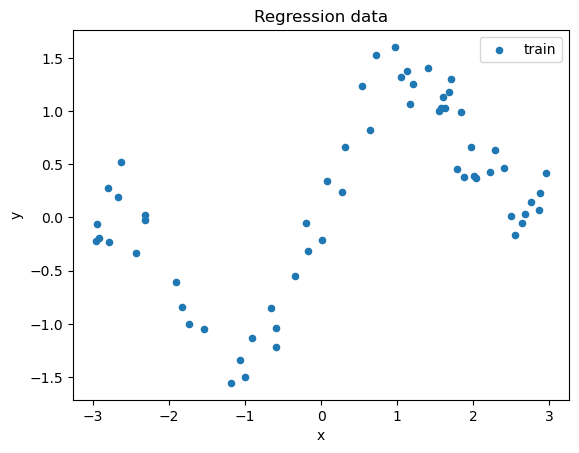

In [2]:
def load_xy(filename):
    data = np.loadtxt(DATA_DIR / filename, delimiter=",", skiprows=1)
    return data[:, 0], data[:, 1]

x_train, y_train = load_xy("train.csv")
x_valid, y_valid = load_xy("valid.csv")
x_test, y_test = load_xy("test.csv")

print("train:", x_train.shape, y_train.shape)
print("valid:", x_valid.shape, y_valid.shape)
print("test :", x_test.shape, y_test.shape)

plt.scatter(x_train, y_train, s=20, label="train")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regression data")
plt.legend()
plt.show()


## Problem 1 — Normal equation

**课堂连接：** Lecture 2，线性模型与最小二乘。

**模型：** 用一条直线 $\hat y=\theta_0+\theta_1x$ 预测 `y`。
把每个输入数 `x_i` 写成一行 `[1, x_i]`，这一步记作 $\phi(x_i)=[1,x_i]$。
将所有行堆叠得到设计矩阵 $X\in\mathbb{R}^{m\times2}$；于是全部预测为 `X @ theta`。
给定的 `add_intercept` 已经完成这一步，不需要再添加一次截距列。

**先推导：** 从 $J(\theta)=\frac{1}{2m}\lVert X\theta-y\rVert^2$ 出发，
令梯度为零，整理成关于 `theta` 的线性方程组，写在下方答题框。

**再实现两个函数：**

1. `fit_normal_equation(X, y)`：接收 `(m, d)` 和 `(m,)`，返回 `(d,)`。
   本题 `d=2`，但不要把 2 写死，P3 会传入更多列。使用 `np.linalg.solve(A, b)`
   求解你推导的方程；它求的是 `A @ theta = b`，不需要显式计算逆矩阵。
2. `mse(y_true, y_pred)`：接收两个同长度的一维数组，返回均方误差
   $\mathrm{MSE}=\frac1m\sum_i(y_i-\hat y_i)^2$。注意 MSE 是 `J` 的两倍。

**检查与交付：** 下格只在训练集拟合，再分别报告 train/valid MSE。
基线是不看 `x`、对所有样本都预测训练集 `y` 均值的模型。
本数据应通过验证 MSE 小于基线的断言；这并不表示直线已解释所有规律。

> **你的答案（请双击本格后填写）**
>
> TODO：写出从令梯度为零到 normal equation 的推导，并标注矩阵 shape。
损失函数为：

$$
J(\theta)=\frac{1}{2m}(X\theta-y)^T(X\theta-y)
$$

其中：

- $X\in\mathbb{R}^{m\times 2}$
- $\theta\in\mathbb{R}^{2}$
- $y\in\mathbb{R}^{m}$

对 $\theta$ 求梯度：

$$
\nabla_\theta J(\theta)
=
\frac{1}{m}X^T(X\theta-y)
$$

在损失函数的最小值处，梯度等于零：

$$
X^T(X\theta-y)=0
$$

展开：

$$
X^TX\theta-X^Ty=0
$$

因此：

$$
X^TX\theta=X^Ty
$$

程序需要求解的线性方程是：

$$
A\theta=b
$$

其中 $A=X^TX\in\mathbb{R}^{2\times2}$，
$b=X^Ty\in\mathbb{R}^{2}$，最终得到
$\theta\in\mathbb{R}^{2}$。

In [6]:
def add_intercept(x):
    return np.column_stack([np.ones_like(x), x])

def fit_normal_equation(X, y):
    # Fit theta without explicitly computing a matrix inverse.
    # START TODO
    A = X.T @ X
    b = X.T @ y
    theta = np.linalg.solve(A, b)
    return theta
    # END TODO

def mse(y_true, y_pred):
    # START TODO
    return np.mean((y_true - y_pred) ** 2)
    # END TODO


In [ ]:
RUN_P1_CHECKS = True
if RUN_P1_CHECKS:
    X_train = add_intercept(x_train)
    X_valid = add_intercept(x_valid)
    theta_ne = fit_normal_equation(X_train, y_train)
    valid_pred = X_valid @ theta_ne
    baseline = np.full_like(y_valid, y_train.mean())
    print("theta:", theta_ne)
    print("train MSE:", mse(y_train, X_train @ theta_ne))
    print("valid MSE:", mse(y_valid, valid_pred))
    print("baseline MSE:", mse(y_valid, baseline))
    assert theta_ne.shape == (2,)
    assert mse(y_valid, valid_pred) < mse(y_valid, baseline)
else:
    print("P1 checks are off.")


## Problem 2 — Gradient descent

**课堂连接：** Lecture 2，迭代优化。

**目标：** 在和 P1 完全相同的训练数据、直线模型和损失 `J` 上，
通过多次小步更新找到参数，比较它与正规方程求解是否一致。

**先写更新式：** 在答题框写出 `J` 对参数的梯度和学习率为 $\alpha$ 时的一次更新。
区分三个量：`predictions` 和 `errors` 都是 `(m,)`；用于画图的 loss 是一个数；
梯度为 `(d,)`，必须和 `theta` 相同。不能用标量 loss 代替逐样本误差来计算梯度。

**函数约定：** `fit_gradient_descent(X, y, learning_rate, steps)` 从零参数开始，
每次用全部训练样本计算 `J` 的梯度，再更新一次参数。返回最终 `(d,)` 参数与一维 `history`。
`learning_rate=0.05` 是每步的步长，`steps=1000` 是更新次数。

**记录与比较：** 在第 0、10、20、… 次更新之前记录当前预测的训练 MSE，
每 10 步向 `history` 追加一个数（1000 次更新时有 100 个记录点）。
这里优化的是 `J=MSE/2`，图上显示的是 MSE；两者最小值位置相同。
下格横轴因此使用 `np.arange(len(history)) * 10`，纵轴为训练 MSE。
先运行 P1 检查格生成 `theta_ne`，再运行本题检查，比较最终参数是否接近。

**合理预期：** 默认步长下 MSE 应下降并逐渐稳定；不要求降到 0。
两种方法得到接近参数说明求解一致，不说明直线模型一定足够好。

> **你的答案（请双击本格后填写）**
>
> TODO：写出一次 gradient-descent update，包括学习率。
$$
\theta = (X^TX)^{-1}(X^T)y
$$

$$
\nabla_\theta J(\theta)
=
\frac{1}{m}X^T(X\theta-y)
$$

$$
\theta \leftarrow \theta - \alpha \nabla_\theta J(\theta)
$$

In [30]:
def fit_gradient_descent(X, y, learning_rate=0.05, steps=1000):
    theta = np.zeros(X.shape[1])
    history = []
    for step in range(steps):
        # START TODO
        predictions = X @ theta
        errors = predictions - y
        gradient = (X.T @ errors) / len(y)
        theta -= learning_rate * gradient
        if step % 10 == 0:
            loss = mse(y, predictions)
            history.append(loss)
        # END TODO
    return theta, np.array(history)


In [ ]:
RUN_P2_CHECKS = True
if RUN_P2_CHECKS:
    theta_gd, history = fit_gradient_descent(add_intercept(x_train), y_train)
    print("GD theta:", theta_gd)
    print("normal-equation theta:", theta_ne)
    assert len(history) > 1 and history[-1] < history[0]
    assert np.allclose(theta_gd, theta_ne, atol=0.1)
    plt.plot(np.arange(len(history)) * 10, history)
    plt.xlabel("step")
    plt.ylabel("training MSE")
    plt.title("Gradient-descent learning curve")
    plt.show()
else:
    print("P2 checks are off. Run P1 first, then complete P2.")


## Problem 3 — Polynomial feature map

**这题在做什么：** P1 只允许拟合直线。如果散点呈现弯曲趋势，继续训练同一条直线
也不会让它变成曲线。本题保留最小二乘的训练方法，改变输入给模型的特征，
比较最高次数为 1、3、10 的三个多项式模型。这是线性回归的扩展练习。

**1. 先读懂符号：把一个数变成一行特征**

$x$ 仍然是原始输入的一个数；`degree`（记作 $k$）表示多项式的最高次数。
$\phi_k$（读作 phi，下标 k）是一个转换规则，称为特征映射：

$$\phi_k(x)=[1,x,x^2,\ldots,x^k].$$

例如 `degree=3` 时，输入 `x=2` 转换为 `[1, 2, 4, 8]`。
第一项 `1` 对应截距，后面依次是原始输入的一次方、二次方、三次方。
这些数都由同一个 `x` 算出，不是新的观测，也不是需要学习的参数。

**2. 明确要拟合的模型**

| degree | 一个样本的特征（代码写法） | 参数个数 |
|---|---|---|
| 1 | `[1, x]` | 2 |
| 3 | `[1, x, x**2, x**3]` | 4 |
| 10 | `[1, x, ..., x**10]` | 11 |

三个模型的预测公式分别为：

$$\begin{aligned}
k=1:&\quad \hat y=\theta_0+\theta_1x,\\
k=3:&\quad \hat y=\theta_0+\theta_1x+\theta_2x^2+\theta_3x^3,\\
k=10:&\quad \hat y=\sum_{j=0}^{10}\theta_jx^j.
\end{aligned}$$

每个 degree 都要**单独训练一组参数**，只使用 `(x_train, y_train)`。
模型可以对 `x` 呈曲线，但参数 `theta` 仍以一次方相加，所以仍可使用 P1 的最小二乘方法。

**3. 你需要实现的部分：`polynomial_features`**

输入 `x` 是包含 `m` 个数的一维数组 `(m,)`，`degree` 是非负整数。
返回矩阵 `Phi`，shape 为 `(m, degree + 1)`：每行对应一个样本，
第 `j` 列为该样本的 `x**j`（列从 0 开始数）。不用自己拟合参数，也不用再调用 `add_intercept`。

用小例子检查接口：`x = np.array([2., 3.])`、`degree=2` 时，应返回

```text
[[1., 2., 4.],
 [1., 3., 9.]]
```

**4. 下面已给出的实验代码会做什么**

1. 对每个 degree 分别生成 `Phi_train` 和 `Phi_valid`；训练集有 60 行，验证集有 40 行。
2. 用 `fit_normal_equation(Phi_train, y_train)` 得到 `(degree + 1,)` 的 `theta_poly`。
3. 用同一组参数计算 `Phi_train @ theta_poly` 和 `Phi_valid @ theta_poly`，
   分别与 `y_train`、`y_valid` 比较得到 train/valid MSE。验证集不能重新训练参数。
4. 在训练输入范围内取 400 个按大小排列的 `grid` 点，用每个模型预测这些点的 `y`。
   **“三条曲线”指三个模型的预测曲线**：横轴是原始 `x`，纵轴是预测的 $\hat y$，
   每条线对应一个 degree；散点是训练数据。不是画三个幂函数，也不是画 loss 随迭代变化。

**完成顺序：** 确保 P1 的 `fit_normal_equation` 和 `mse` 已定义并可用，填写本题唯一的
函数 TODO，运行函数定义格，再将 `RUN_P3_CHECKS=True` 并运行检查格。
实验循环、MSE 输出和绘图已经提供，不需要重写。

**5. 需要交付和解释什么**

保留三行 degree/train MSE/valid MSE 输出及一张含三条预测曲线的图。在答题框回答：

- 哪个 degree 的验证 MSE 最低？按本次实验你会选择哪个？
- 若简单模型训练、验证误差都较高，且曲线错过明显弯曲趋势，这是欠拟合的证据。
- 若提高次数使训练误差下降、验证误差反而上升，或曲线出现数据不支持的剧烈摆动，
  才有理由怀疑过拟合。**不要预先认定 degree=10 一定过拟合**；证据不足时明确写出。

高次幂还可能放大数值误差。若求解报错或曲线异常，先核对特征列和 shape；
不要直接把数值问题解释成过拟合。比较未正则化模型时，训练 MSE 通常应随次数增加而不升高。

In [ ]:
def polynomial_features(x, degree):
    # Return shape (m, degree + 1), including the intercept column.
    # START TODO
    raise NotImplementedError("Build powers 0 through degree")
    # END TODO


In [ ]:
RUN_P3_CHECKS = False
if RUN_P3_CHECKS:
    example = polynomial_features(np.array([2., 3.]), 2)
    assert example.shape == (2, 3)
    assert np.allclose(example, [[1., 2., 4.], [1., 3., 9.]])
    grid = np.linspace(x_train.min(), x_train.max(), 400)
    plt.figure(figsize=(9, 4))
    for degree in (1, 3, 10):
        Phi_train = polynomial_features(x_train, degree)
        Phi_valid = polynomial_features(x_valid, degree)
        assert Phi_train.shape == (len(x_train), degree + 1)
        assert Phi_valid.shape == (len(x_valid), degree + 1)
        theta_poly = fit_normal_equation(Phi_train, y_train)
        train_mse = mse(y_train, Phi_train @ theta_poly)
        valid_mse = mse(y_valid, Phi_valid @ theta_poly)
        print(f"degree={degree:2d} train={train_mse:.4f} valid={valid_mse:.4f}")
        plt.plot(grid, polynomial_features(grid, degree) @ theta_poly, label=f"degree {degree}")
    plt.scatter(x_train, y_train, s=15, color="black", alpha=0.5, label="train data")
    plt.xlabel("x")
    plt.ylabel("y / predicted y")
    plt.legend()
    plt.title("Polynomial regression")
    plt.show()
else:
    print("P3 checks are off. Complete P1 first.")


> **你的答案（请双击本格后填写）**
>
> TODO：列出三个 degree 的 train/valid MSE，选择验证 MSE 最低者；结合曲线说明欠拟合或过拟合的证据，证据不足也请说明。

## Problem 4 — Locally weighted regression

**课堂连接：** Lecture 3，LWR。

**目标：** 预测某个位置 `q` 时，让离它近的训练样本更有影响。
和 P1 的全局直线不同，本题为每个查询位置重新拟合一条局部直线，只取这条直线在 `q` 处的预测。

**输入与输出：** `x_train`、`y_train` 为 `(m,)`，`x_query` 是待预测位置组成的 `(n,)` 数组，
`tau` 是正数，控制邻域宽度。`predict_lwr` 返回 `(n,)`，不需要查询点的真实 `y`。

**对 `x_query` 中的每个位置 `q`，依次做：**

1. 构造训练设计矩阵 `X=add_intercept(x_train)`，每行仍为 `[1, x_i]`。
2. 计算每条训练样本相对 `q` 的权重
   $w_i(q)=\exp(-(x_i-q)^2/(2\tau^2))$。距离越远，权重越小。
3. 令 `W` 为对角线上放这些权重的 `(m,m)` 矩阵。对局部损失
   $J_q(\theta)=\frac12\sum_i w_i(q)(\theta_0+\theta_1x_i-y_i)^2$
   求梯度并令其为零，得到加权正规方程，用 `np.linalg.solve` 求局部 `(2,)` 参数。
4. 用 `[1, q]` 与局部参数计算一个预测值，按查询点顺序存入输出。
   可以循环查询点；每换一个 `q` 都要重新算权重和参数。

**实验与交付：** 下格分别用 `tau=0.1, 0.5, 2.0` 预测验证集并输出 MSE，
再在 `grid` 上画三条预测曲线（横轴 `x`，纵轴预测 `y`）。
在答题框写出加权正规方程，比较三组结果并选择验证误差最低的 tau。
小 tau 往往更灵活，大 tau 往往更平滑；不要求本次结果严格遵循某个排名。

In [ ]:
def predict_lwr(x_train, y_train, x_query, tau):
    # Return one LWR prediction per query point.
    # START TODO
    raise NotImplementedError("Compute weights and solve one local model per query")
    # END TODO


In [ ]:
RUN_P4_CHECKS = False
if RUN_P4_CHECKS:
    grid = np.linspace(x_train.min(), x_train.max(), 300)
    for tau in (0.1, 0.5, 2.0):
        valid_pred = predict_lwr(x_train, y_train, x_valid, tau)
        print(f"tau={tau:.1f} valid MSE={mse(y_valid, valid_pred):.4f}")
        plt.plot(grid, predict_lwr(x_train, y_train, grid, tau), label=f"tau={tau}")
    plt.scatter(x_train, y_train, s=15, color="black", alpha=0.5)
    plt.xlabel("x")
    plt.ylabel("y / predicted y")
    plt.legend()
    plt.title("Locally weighted regression")
    plt.show()
else:
    print("P4 checks are off.")


> **你的答案（请双击本格后填写）**
>
> TODO：写出加权正规方程；列出各 tau 的 valid MSE 和选择。结合曲线解释小邻域对局部噪声的敏感性，以及大邻域可能遗漏的变化。

## Checks

- [ ] 所有设计矩阵的第一列都是 1。
- [ ] 没有显式计算矩阵逆；使用 `np.linalg.solve`。
- [ ] gradient descent 与 normal equation 得到接近的参数。
- [ ] 对 polynomial degree 和 LWR tau 的判断来自验证集，不来自测试集。

## Next Steps

完成 PS1 后再进入分类；不要提前使用分类指标解释回归模型。